# Full continental run — SIMPLACE and TorchCrop, together

**What this notebook does.** It reads each model's own `winter_wheat_2000_2024`
production run exactly as
[`submit/submit_cropmodelling.sh`](../submit/submit_cropmodelling.sh) writes
it — `cm4eu simplace collect`'s `simplace_europe.parquet` and the shard
combine's `torchcrop_europe.parquet` — compares both against the CyBench
national yield and phenology statistics (§4-5), and then compares the two
models directly against each other over the whole domain (§6).

**How this differs from the other two-model notebooks.**
`germany_smoke_evaluation.ipynb` matches 30 cells and hands SIMPLACE's own
simulated sowing dates to torchcrop by construction; `stresstest_evaluation.ipynb`
forces every non-model input equal (crop parameters, spin-up, irrigation,
CO₂). Neither one is what ships. This notebook reads whatever each pipeline
actually produced for the full run — a different sowing convention on each
side unless the run was submitted through the chain (SIMPLACE's simulated
dates handed to torchcrop), a cell set that need not match exactly — because
the question here is what the delivered output says, not an idealised
comparison.

**The one difference §2 does not leave alone is the year range.**
`season.start_year`/`end_year` (which torchcrop honours) and
`simplace.start_date`/`end_date` (which SIMPLACE honours) are independent
`config.yaml` knobs, and this run set them inconsistently: SIMPLACE simulated
1979-2024 while torchcrop simulated only its configured 2000-2024. Comparing
either model's full record against CyBench, or the two against each other,
would silently mix in 20 SIMPLACE-only seasons no torchcrop number ever saw.
§2 trims every model down to the seasons they share before anything else
runs; the raw parquet files still carry the extra seasons.

**Either run can be missing, and the notebook says so rather than failing.**
`fullrun.load_runs` skips a model with no Parquet yet and logs a warning; §2
reports which models loaded. §4-5 run per model over whichever are present;
§6, which needs both, prints a note and stops there if only one is.

Four conventions carried over from the single-model notebooks:

1. **Error is `simulated − observed`** against CyBench (§4-5); `torchcrop −
   simplace` in the direct comparison (§6), where neither side is a
   reference — see `evaluation.fullrun.pair_models`.
2. **No moisture conversion.** Both models report grain dry matter; CyBench
   reports market moisture (~13.5 %), so part of any negative bias against it
   is that unit difference rather than model error.
3. **The simulated national mean is unweighted** over cropland cells — the
   export carries no per-cell wheat area to weight by.
4. **Day-of-year statistics are circular** (`doy.circular_mean_doy`,
   `doy.doy_difference`), for the reason `phenology_evaluation.ipynb`'s header
   gives: Spain's regional `sos` runs from DOY 0.7 to 363.

All reusable code is in
[`../src/cropmodelling4eu/evaluation/`](../src/cropmodelling4eu/evaluation/);
this notebook is the workflow only.

## 0. Setup

In [1]:
import logging
import sys
from pathlib import Path

# cropmodelling4eu is installed (pip install -e .), so the evaluation
# library is imported like any other package rather than off sys.path.

import colormaps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from cropmodelling4eu.evaluation import aggregate, config, cybench, doy, fullrun, metrics, plots, regions, torchcrop
from cropmodelling4eu.evaluation.style import use_style

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s",
                    force=True)
logging.getLogger("matplotlib").setLevel(logging.WARNING)

PALETTE = use_style("light")
config.ensure_output_dirs()

pd.set_option("display.max_rows", 60)
pd.set_option("display.width", 140)

print(f"SIMPLACE run  : {config.SIMPLACE_PARQUET}",
      "(found)" if config.SIMPLACE_PARQUET.is_file() else "(not finished yet)")
print(f"TorchCrop run : {config.SIM_PARQUET}",
      "(found)" if config.SIM_PARQUET.is_file() else "(not finished yet)")
print(f"CyBench root  : {config.CYBENCH_ROOT}")
print(f"Outputs       : {config.OUTPUT_DIR}")

SIMPLACE run  : /data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/winter_wheat_2000_2024/simplace/simplace_europe.parquet (found)
TorchCrop run : /data01/FDS/muduchuru/Data/SIMPLACE/cropmodelling4eu/winter_wheat_2000_2024/torchcrop/torchcrop_europe.parquet (found)
CyBench root  : /data01/FDS/muduchuru/Data/Agri/cybench
Outputs       : /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs


## 1. Scope — which countries are evaluable

A country needs a CyBench yield file *and* CyBench polygons: the file supplies
the reference, the polygons decide which 10 km cells belong to it.

In [2]:
COUNTRIES = config.available_countries()

scope = pd.DataFrame({
    "code": list(config.TARGET_COUNTRIES),
    "name": [config.COUNTRY_NAMES.get(c, c) for c in config.TARGET_COUNTRIES],
    "eu27": [c in config.EU27 for c in config.TARGET_COUNTRIES],
    "schengen_non_eu": [c in config.SCHENGEN_NON_EU for c in config.TARGET_COUNTRIES],
    "in_cybench": [c in COUNTRIES for c in config.TARGET_COUNTRIES],
}).set_index("code")

print(f"{len(COUNTRIES)} of {len(config.TARGET_COUNTRIES)} target countries are evaluable")
print("missing:", ", ".join(scope.index[~scope["in_cybench"]]))
scope

23 of 31 target countries are evaluable
missing: CH, CY, IS, LI, LU, MT, NO, SI


,name,eu27,schengen_non_eu,in_cybench
code,,,,
AT,Austria,True,False,True
BE,Belgium,True,False,True
BG,Bulgaria,True,False,True
CH,Switzerland,False,True,False
CY,Cyprus,True,False,False
CZ,Czechia,True,False,True
DE,Germany,True,False,True
DK,Denmark,True,False,True
EE,Estonia,True,False,True


## 2. Load both runs

One row per (cell, season) on each side. `fullrun.load_runs` reads each with
its own model's rules — SIMPLACE's collector already writes the dates it
simulated, torchcrop's `days_to_maturity` is turned into dates by
`torchcrop.add_phenology_columns` — and tags every row with `model`. A model
with no Parquet yet is skipped with a warning, not raised on.

In [3]:
runs = fullrun.load_runs()
print(f"\nmodels loaded: {', '.join(runs)}")
for model, frame in runs.items():
    print(f"{model:10s}: {len(frame):>9,} cell-seasons, "
          f"{frame['SimplaceID'].nunique():>6,} cells, "
          f"{frame['year'].min()}-{frame['year'].max()}")

pd.concat(
    {model: frame[["yield_t_ha", "days_to_maturity"]].describe()
     for model, frame in runs.items()},
    axis=1,
)

INFO cropmodelling4eu.evaluation.torchcrop: read torchcrop_europe.parquet: 1711510 rows, 20 columns
INFO cropmodelling4eu.evaluation.torchcrop: using the run's own per-cell sowing date (139 distinct values, 215-366)
WARNING cropmodelling4eu.evaluation.torchcrop: 12798 of 1711510 rows (0.75%) never reached maturity; their dates are NaN
INFO cropmodelling4eu.evaluation.fullrun: torchcrop: 1711510 cell-seasons, 68685 cells, 2000-2024
INFO cropmodelling4eu.evaluation.fullrun: simplace: 3070021 cell-seasons, 68685 cells, 1979-2024



models loaded: torchcrop, simplace
torchcrop : 1,711,510 cell-seasons, 68,685 cells, 2000-2024
simplace  : 3,070,021 cell-seasons, 68,685 cells, 1979-2024


torchcrop                       simplace                 
         yield_t_ha days_to_maturity    yield_t_ha days_to_maturity
count  1.711510e+06     1.698712e+06  3.070021e+06     3.070021e+06
mean   5.089333e+00     3.130158e+02  5.338807e+00     3.012577e+02
std    3.042100e+00     4.607144e+01  2.430528e+00     6.674079e+01
min    0.000000e+00     1.440000e+02  1.528874e-02     1.000000e+00
25%    2.161313e+00     2.880000e+02  3.454936e+00     2.900000e+02
50%    5.907524e+00     3.190000e+02  5.319343e+00     3.170000e+02
75%    7.747307e+00     3.450000e+02  7.225859e+00     3.390000e+02
max    1.190326e+01     5.350000e+02  1.449041e+01     3.650000e+02

In [4]:
# Constrain every model to the seasons they *all* cover. `season.start_year`/
# `end_year` (torchcrop) and `simplace.start_date`/`end_date` are independent
# config knobs -- this run set them inconsistently, so SIMPLACE simulated
# 1979-2024 while torchcrop simulated only its configured 2000-2024. Trimming
# here, once, means every section below (CyBench comparisons in §4-5 as well
# as the direct comparison in §6) reads the same window on both sides, rather
# than SIMPLACE's extra 1979-1999 seasons only dropping out of §6's inner join.
common_years = set.intersection(*(set(frame["year"].unique()) for frame in runs.values()))
lo, hi = min(common_years), max(common_years)
print(f"Constraining every model to the {len(common_years)} seasons they share ({lo}-{hi}).")

for model in list(runs):
    before = len(runs[model])
    runs[model] = runs[model][runs[model]["year"].isin(common_years)].copy()
    dropped = before - len(runs[model])
    if dropped:
        print(f"  {model:10s}: dropped {dropped:>9,} cell-seasons outside the shared window "
              f"({len(runs[model]):,} remain)")

Constraining every model to the 25 seasons they share (2000-2024).
  simplace  : dropped 1,358,511 cell-seasons outside the shared window (1,711,510 remain)


## 3. Assign each 10 km cell to a country

Built from the **union** of both models' cells: both pipelines read the same
10 km export, so they share one grid, and one country join covers whichever
model (or both) is present. Cells outside the CyBench footprint — the UK,
Norway, Switzerland, the western Balkans, North Africa — are dropped from
every model.

In [5]:
all_cells = torchcrop.simulation_cells(
    pd.concat([frame[["SimplaceID", "lon", "lat"]] for frame in runs.values()],
              ignore_index=True)
)
all_cells = regions.assign_cells_to_countries(
    all_cells, COUNTRIES, cache=regions.default_cache_path(len(COUNTRIES))
)
print(f"{all_cells['country'].notna().sum():,} of {len(all_cells):,} cells "
      f"inside the CyBench footprint ({all_cells['snapped'].sum():,} matched "
      f"by the {config.SNAP_KM} km snap)")

scoped = {}
for model, frame in runs.items():
    tagged = frame.merge(all_cells[["SimplaceID", "country", "snapped"]],
                          on="SimplaceID", how="left")
    scoped[model] = tagged[tagged["country"].notna()].copy()
    print(f"{model:10s}: {len(scoped[model]):>9,} of {len(frame):>9,} "
          f"cell-seasons kept")

cells_per_country = (
    all_cells.dropna(subset=["country"]).groupby("country").size()
    .rename("cells").to_frame()
)
cells_per_country.T

INFO cropmodelling4eu.evaluation.torchcrop: 68685 unique cells
INFO cropmodelling4eu.evaluation.regions: cell-to-country map read from /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/cache/cell_country_n23_snap5km.parquet


30,406 of 68,685 cells inside the CyBench footprint (779 matched by the 5.0 km snap)
torchcrop :   759,975 of 1,711,510 cell-seasons kept
simplace  :   759,975 of 1,711,510 cell-seasons kept


country,AT,BE,BG,CZ,DE,DK,EE,EL,ES,FI,...,IE,IT,LT,LV,NL,PL,PT,RO,SE,SK
cells,398,378,978,826,4297,729,471,602,3258,120,...,279,1710,861,757,424,3880,376,2025,778,465


## 4. National yield — both models against CyBench

Same pipeline as `yield_evaluation.ipynb` §4-8, run once per loaded model. The
CyBench side (§4.2) does not depend on the model, so it is aggregated once and
paired against each.

### 4.1 Aggregate each model to national means, and pair against CyBench

In [6]:
obs = cybench.load_yield(COUNTRIES)
obs_country = aggregate.aggregate_observed_yield(obs)
print(obs_country["obs_method"].value_counts().to_string())

yield_paired = []
for model, frame in scoped.items():
    sim_country = aggregate.aggregate_simulated(frame, {"yield_t_ha": False})
    paired = aggregate.pair_observations(sim_country, obs_country, ["country", "year"])
    paired["model"] = model
    paired["residual"] = paired["yield_t_ha"] - paired["obs_yield"]
    yield_paired.append(paired)
yield_paired = pd.concat(yield_paired, ignore_index=True)

print(f"\n{len(yield_paired)} paired (model, country, year) rows across "
      f"{yield_paired['country'].nunique()} countries")
yield_paired.head()

INFO cropmodelling4eu.evaluation.cybench: dropped 28 rows with a missing or non-positive yield
INFO cropmodelling4eu.evaluation.cybench: observed yields: 24735 rows, 23 countries, 1979-2021, 54% area-weighted
INFO cropmodelling4eu.evaluation.aggregate: observed yields: 485 country-years, 93% area-weighted


obs_method
weighted      453
unweighted     32


INFO cropmodelling4eu.evaluation.aggregate: simulated: 575 country-groups, 55-5300 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 412 rows; 163 simulated-only and 73 observed-only dropped
INFO cropmodelling4eu.evaluation.aggregate: simulated: 575 country-groups, 55-5300 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 412 rows; 163 simulated-only and 73 observed-only dropped



824 paired (model, country, year) rows across 23 countries


,country,year,yield_t_ha,sim_method,n_cells,obs_yield,obs_method,n_regions,model,residual
0,AT,2000,6.225767,unweighted,398,4.549300,weighted,5,torchcrop,1.676466
1,AT,2001,7.364303,unweighted,398,5.302246,weighted,5,torchcrop,2.062057
2,AT,2002,6.792408,unweighted,398,5.013319,weighted,5,torchcrop,1.779088
3,AT,2003,4.848339,unweighted,398,4.386834,weighted,4,torchcrop,0.461504
4,AT,2004,8.257205,unweighted,398,6.070916,weighted,4,torchcrop,2.186289


### 4.2 Pooled skill, both models

In [7]:
yield_pooled = {
    model: metrics.yield_metrics(block["obs_yield"], block["yield_t_ha"])
    for model, block in yield_paired.groupby("model")
}
yield_pooled_table = pd.DataFrame(yield_pooled).T[list(metrics.YIELD_METRIC_ORDER)]
yield_pooled_table.round(3)

,n,obs_mean,sim_mean,bias,mae,rmse,mape,r2,pearson_r
simplace,412.0,5.083,6.061,0.978,1.873,2.377,53.64,-0.370,0.284
torchcrop,412.0,5.083,6.374,1.291,1.998,2.565,59.76,-0.596,0.307


### 4.3 Per-country skill, both models

One RMSE/Bias/Pearson r table per model, side by side, so a country either
model struggles with is visible at a glance rather than in two separate
notebooks.

In [8]:
yield_by_country = {
    model: metrics.metrics_by_group(block, "obs_yield", "yield_t_ha")
    for model, block in yield_paired.groupby("model")
}
yield_comparison = pd.concat(
    {model: table[["n", "bias", "rmse", "pearson_r"]]
     for model, table in yield_by_country.items()},
    axis=1,
)
yield_comparison.to_csv(
    config.TABLE_DIR / "full_run_yield_metrics_by_country.csv", float_format="%.3f"
)
yield_comparison.round(2)

simplace                       torchcrop                      
               n  bias  rmse pearson_r         n  bias  rmse pearson_r
country                                                               
AT            21  1.40  1.67      0.48        21  2.03  2.14      0.60
BE            21 -1.99  2.41     -0.17        21 -1.24  1.42      0.45
BG            10  1.00  1.85     -0.07        10 -0.31  2.19     -0.52
CZ            21  0.65  1.48      0.05        21  1.31  1.75      0.26
DE            22 -1.14  1.36      0.41        22 -0.31  0.78      0.44
DK            15 -0.74  1.25      0.37        15 -0.33  0.98      0.50
EE            17  2.96  3.21      0.49        17  3.71  3.91      0.59
EL            20  2.25  2.33      0.20        20  2.49  2.65      0.14
ES            21  1.42  1.63      0.86        21  1.18  1.65      0.84
FI            21  1.88  2.24      0.14        21  1.10  1.66      0.38
FR            21 -0.80  1.54     -0.16        21 -0.74  1.14      0.22
HR            13  0.68  1.90     -0.65        13  0.81  1.22     -0.05
HU            19 -0.66  1.76      0.12        19 -0.20  1.40      0.40
IE             5 -1.11  1.49      0.44         5 -1.86  2.10      0.51
IT            21  0.88  1.36      0.07        21  1.50  1.72      0.22
LT            21  3.09  3.28      0.52        21  3.71  3.80      0.58
LV            19  3.64  3.82      0.56        19  4.07  4.19      0.57
NL            21 -1.27  1.75     -0.10        21 -1.27  1.37      0.58
PL            18  1.83  2.19      0.37        18  3.16  3.22      0.67
PT            21  5.18  5.44      0.32        21  6.20  6.23      0.63
RO            21  0.99  1.62      0.37        21  0.14  1.47      0.22
SE            21  0.02  1.03      0.36        21  0.40  1.06      0.55
SK             2  0.39  0.50       NaN         2  1.08  1.12       NaN
ALL          412  0.98  2.38      0.28       412  1.29  2.56      0.31

### 4.4 Figures, one per model

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_01_yield_scatter_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_01_yield_scatter_torchcrop(.png/.pdf)


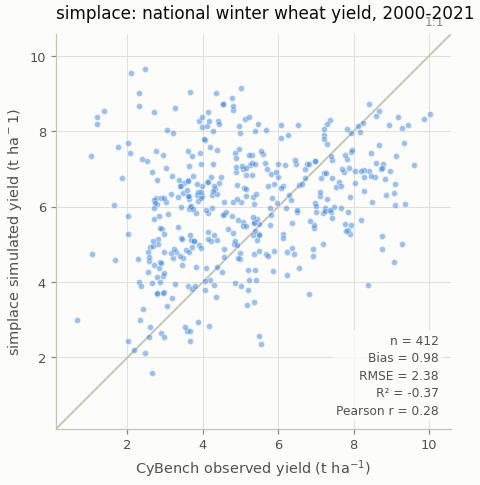

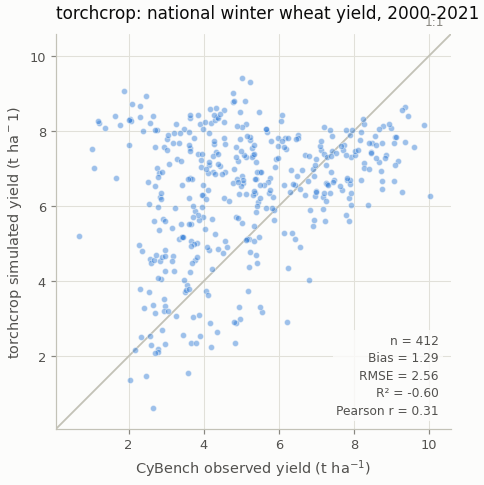

In [9]:
for model, block in yield_paired.groupby("model"):
    fig = plots.scatter_one_to_one(
        block, "obs_yield", "yield_t_ha", stats=yield_pooled[model],
        title=f"{model}: national winter wheat yield, "
              f"{block['year'].min()}-{block['year'].max()}",
        xlabel="CyBench observed yield (t ha$^{-1}$)",
        ylabel=f"{model} simulated yield (t ha$^{-1}$)",
    )
    plots.save(fig, f"full_run_01_yield_scatter_{model}")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_02_yield_bias_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_02_yield_bias_torchcrop(.png/.pdf)


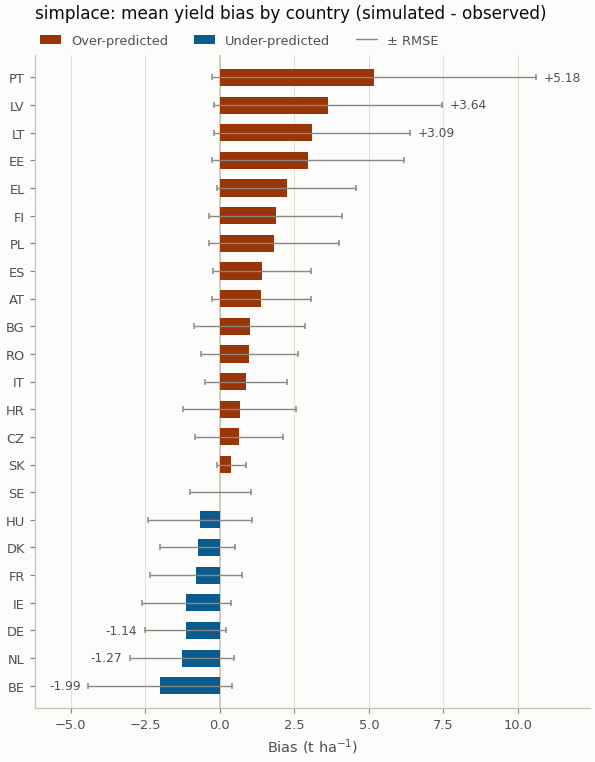

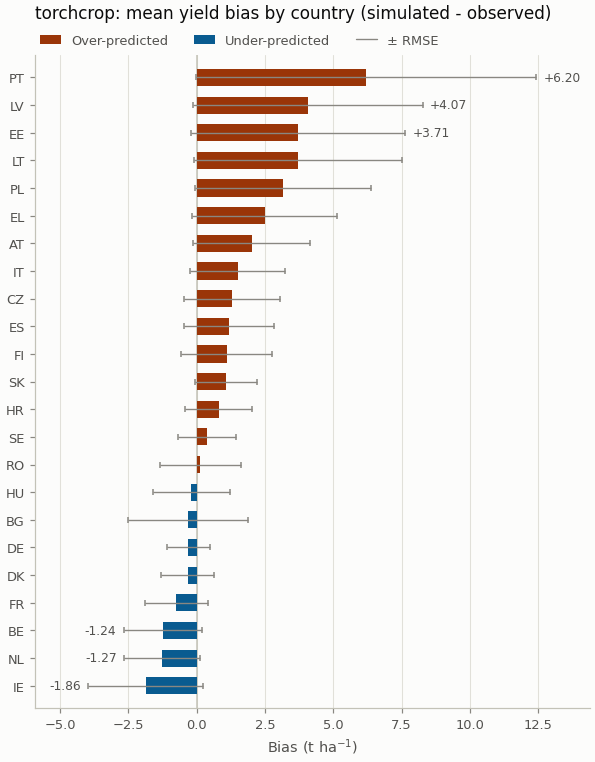

In [10]:
for model, table in yield_by_country.items():
    ranked = metrics.rank_countries(table, by="rmse")
    fig = plots.bias_bars(
        ranked, value_col="bias", error_col="rmse",
        title=f"{model}: mean yield bias by country (simulated - observed)",
        xlabel="Bias (t ha$^{-1}$)",
    )
    plots.save(fig, f"full_run_02_yield_bias_{model}")
    # display(fig)

### 4.5 Figures — spatial maps, both models

Where §4.3 gives a per-country number, these put it on the map: the cell-level
mean shows the field each national average is drawn from, and the choropleth
repeats §4.3's bias per country in the shape a reader recognises faster than a
table.

INFO cropmodelling4eu.evaluation.regions: 946 admin polygons across 23 countries
INFO cropmodelling4eu.evaluation.regions: dissolved to 23 national footprints
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_06_yield_map_torchcrop(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_06_yield_map_simplace(.png/.pdf)


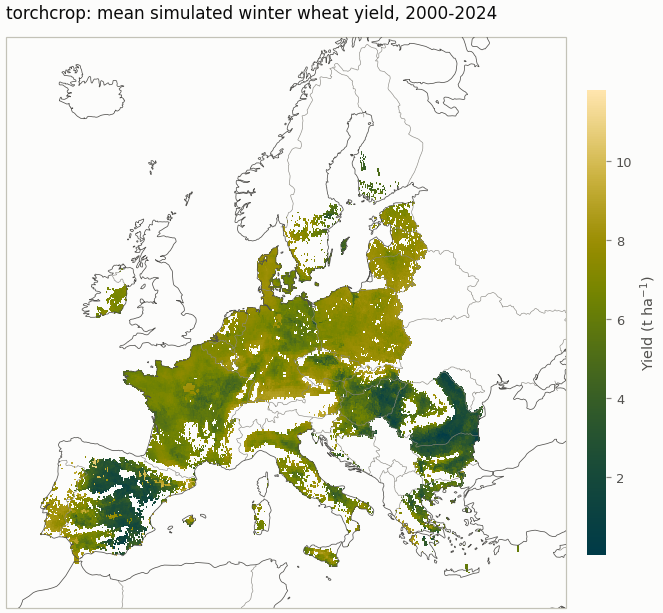

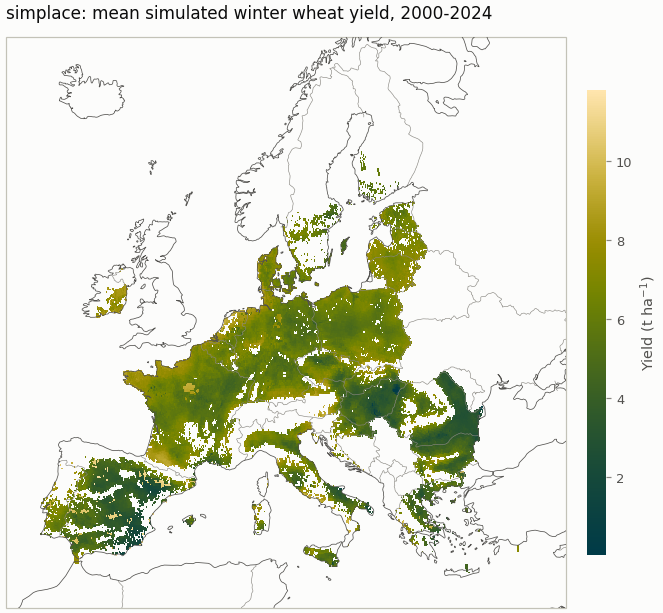

In [11]:
polygons = regions.load_country_polygons(COUNTRIES)

cell_means = {
    model: frame.groupby(["SimplaceID", "lon", "lat"], as_index=False)["yield_t_ha"].mean()
    for model, frame in scoped.items()
}
# One shared scale across both models -- otherwise a pale SIMPLACE map next to
# a saturated TorchCrop one would hide a real difference behind mismatched bars.
yield_vmin = min(cm["yield_t_ha"].min() for cm in cell_means.values())
yield_vmax = max(cm["yield_t_ha"].max() for cm in cell_means.values())

for model, cell_mean in cell_means.items():
    frame = scoped[model]
    fig = plots.cell_map(
        cell_mean, "yield_t_ha",
        cmap=colormaps.bamako, vmin=yield_vmin, vmax=yield_vmax,
        title=f"{model}: mean simulated winter wheat yield, "
              f"{frame['year'].min()}-{frame['year'].max()}",
        cbar_label="Yield (t ha$^{-1}$)",
    )
    plots.save(fig, f"full_run_06_yield_map_{model}")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_07_yield_bias_map_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_07_yield_bias_map_torchcrop(.png/.pdf)


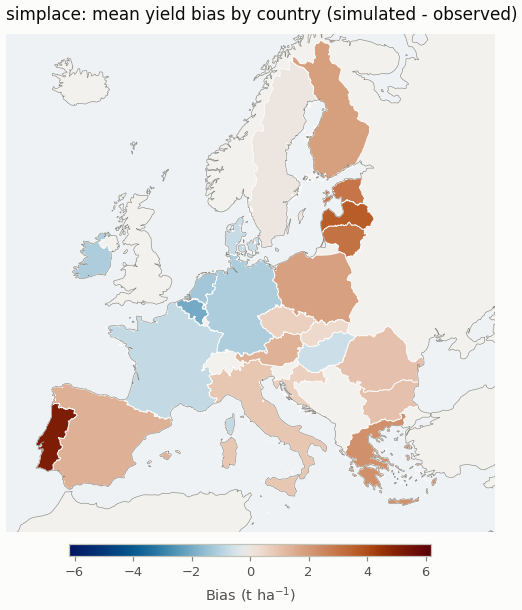

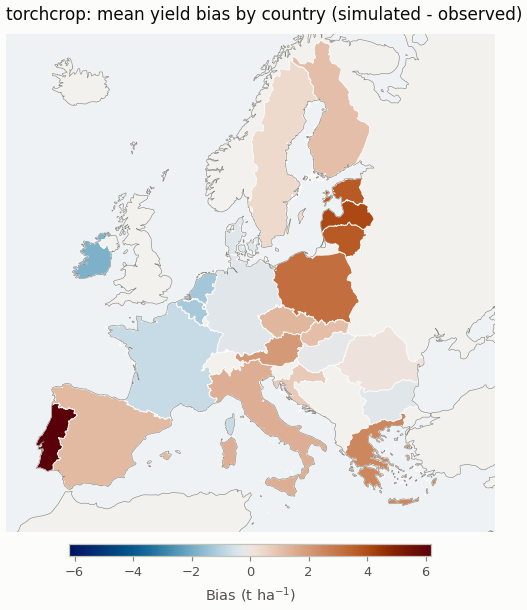

In [12]:
# Shared vmax so a country that is +2 t/ha in one model paints the same red
# it would in the other, rather than each map auto-scaling to its own extreme.
yield_bias_vmax = max(table["bias"].abs().max() for table in yield_by_country.values())

for model, table in yield_by_country.items():
    fig = plots.country_choropleth(
        polygons, table["bias"],
        cmap=colormaps.vik, vmax=yield_bias_vmax,
        title=f"{model}: mean yield bias by country (simulated - observed)",
        cbar_label="Bias (t ha$^{-1}$)", diverging=True,
    )
    plots.save(fig, f"full_run_07_yield_bias_map_{model}")
    # display(fig)

### 4.6 Overview panel — yield, inter-annual spread, and bias, side by side

One figure with everything §4.1-4.5 established separately: top row is
national mean yield — CyBench, then each model, one shared colour scale
across all three (the same reasoning as §4.5's cell maps: a paler map next to
a saturated one must not be mistaken for a real difference). Bottom row has no
such shared axis for the first panel — CyBench's own inter-annual std is a
different quantity from a model's bias against it — but the two bias panels
do share one, again for comparability. Each panel carries the pooled mean of
what it shows, so the map and the number never disagree.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_11_yield_overview_panel(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_11_yield_overview_panel.png')

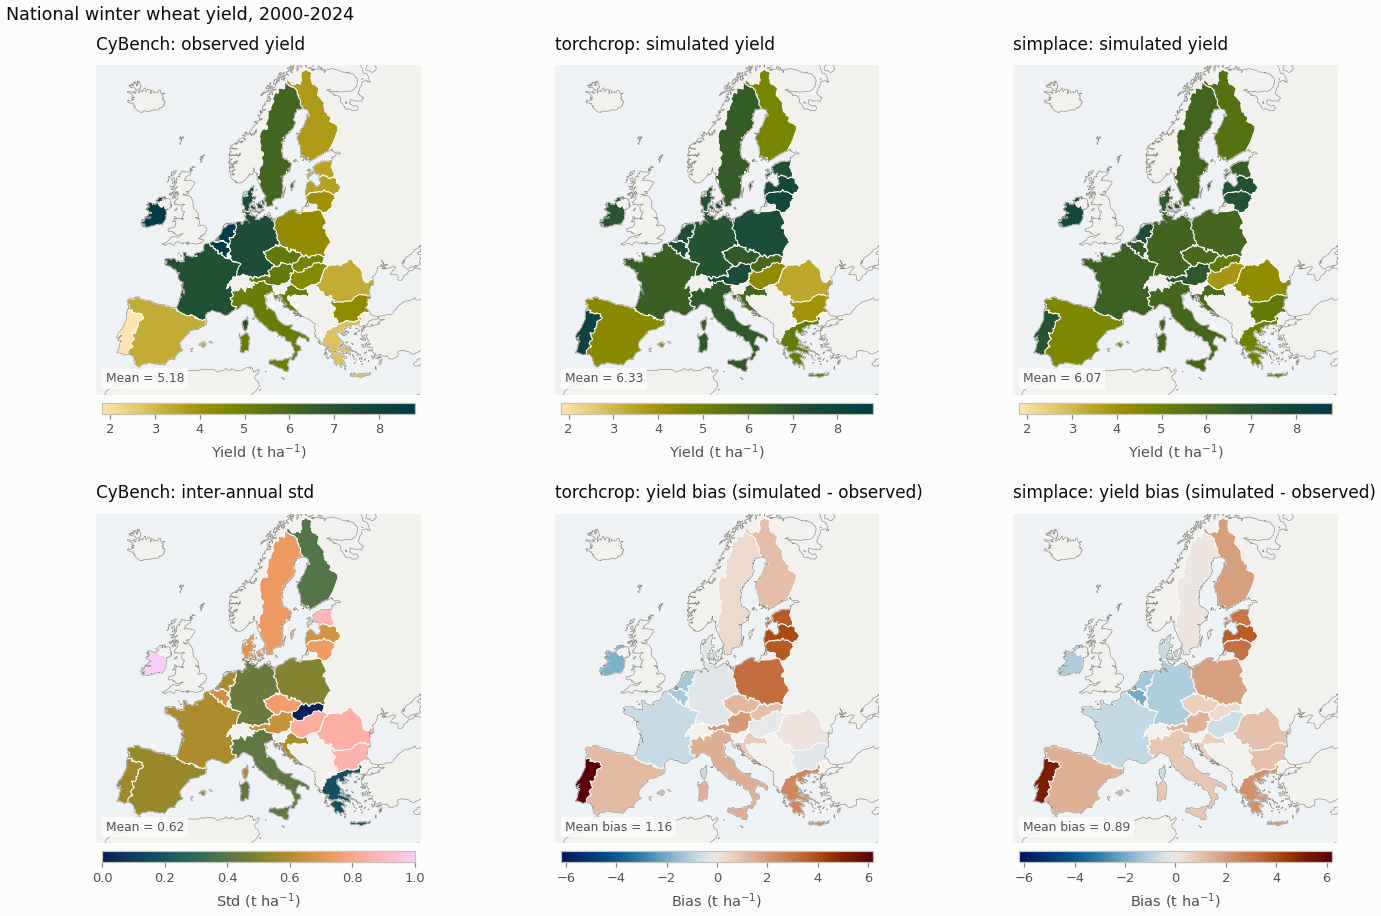

In [13]:
model_order = [m for m in ("torchcrop", "simplace") if m in yield_paired["model"].unique()]

# CyBench mean and inter-annual std per country, over the shared window §2 set.
obs_window = obs_country[obs_country["year"].isin(common_years)]
obs_mean = obs_window.groupby("country")["obs_yield"].mean()
obs_std = obs_window.groupby("country")["obs_yield"].std()

model_mean = {
    m: yield_paired.loc[yield_paired["model"] == m].groupby("country")["yield_t_ha"].mean()
    for m in model_order
}
model_bias = {m: yield_by_country[m]["bias"] for m in model_order}  # carries the pooled "ALL" row

# Row 1: one shared scale across CyBench and every model's mean yield.
row1 = [obs_mean, *model_mean.values()]
yield_vmin = min(v.min() for v in row1)
yield_vmax = max(v.max() for v in row1)

# Row 2 bias panels: one shared symmetric scale across every model; std keeps its own.
bias_vmax = max(model_bias[m].drop("ALL", errors="ignore").abs().max() for m in model_order)

n_cols = 1 + len(model_order)
fig, axes = plt.subplots(
    2, n_cols, figsize=(4.4 * n_cols, 8.6),
    subplot_kw={"projection": plots.EUROPE_PROJECTION},
)

plots.country_choropleth(
    polygons, obs_mean, ax=axes[0, 0], diverging=False,
    vmin=yield_vmin, vmax=yield_vmax, cmap=colormaps.bamako_r,
    title="CyBench: observed yield", cbar_label="Yield (t ha$^{-1}$)",
    mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    plots.country_choropleth(
        polygons, model_mean[m], ax=axes[0, i], diverging=False,
        vmin=yield_vmin, vmax=yield_vmax, cmap=colormaps.bamako_r,
        title=f"{m}: simulated yield", cbar_label="Yield (t ha$^{-1}$)",
        mean_label="Mean",
    )

plots.country_choropleth(
    polygons, obs_std, ax=axes[1, 0], diverging=False, cmap=colormaps.batlow,
    title="CyBench: inter-annual std", cbar_label="Std (t ha$^{-1}$)",
    mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    plots.country_choropleth(
        polygons, model_bias[m], ax=axes[1, i], diverging=True,
        vmax=bias_vmax, cmap=colormaps.vik,
        title=f"{m}: yield bias (simulated - observed)",
        cbar_label="Bias (t ha$^{-1}$)", mean_label="Mean bias",
    )

fig.suptitle(
    f"National winter wheat yield, {min(common_years)}-{max(common_years)}",
    x=0.01, ha="left", color=PALETTE["primary"], fontsize=plt.rcParams["font.size"] + 2,
)
fig.tight_layout()
plots.save(fig, "full_run_11_yield_overview_panel")
# display(fig)

## 5. Phenology — both models against CyBench

Same three stages as `phenology_evaluation.ipynb` — sowing, maturity, harvest
— for whichever models are loaded. Read `config.STAGES[*].caveat` before the
sowing and harvest numbers: sowing is a weak pairing whenever a model's
`sowing_doy` is a constant rather than a per-cell result, and harvest repeats
maturity while `HARVEST_LAG_DAYS = 0`.

In [14]:
for stage in config.STAGES:
    print(f"{stage.label:9s} <- {stage.sim_col:14s} vs CyBench '{stage.obs_col}'")
    print(f"  {stage.caveat}\n")

Sowing    <- sowing_doy     vs CyBench 'sos'
  Weak pairing. The simulated date is a constant model input (DOY 270), not a prediction, so its only degree of freedom is a single continental offset. CyBench 'sos' is a start-of-season, and it switches convention with climate: ~DOY 330-360 in ES/EL/PT/southern IT (autumn sowing) but ~DOY 40-75 in DE/PL/EE/LV (post-winter green-up). Read the northern residuals as a convention difference, not a model error.

Maturity  <- maturity_doy   vs CyBench 'eos'
  Strongest pairing. Simulated maturity is the first day at DVS >= 2; CyBench 'eos' is the end of season, which for winter wheat falls at harvest (~DOY 205-225). The residual absorbs the maturity-to-harvest interval as well as any model error.

Harvest   <- harvest_doy    vs CyBench 'eos'
  Identical to maturity while HARVEST_LAG_DAYS = 0: LINTUL-5 stops the crop at DVS = 2 and models no drydown, so it predicts no harvest date of its own. Raise the lag to test a drydown assumption; the row is 

### 5.1 Aggregate each model's stage dates, and pair against the CyBench calendar

In [15]:
STAGE_COLS = {stage.sim_col: True for stage in config.STAGES}

calendar = cybench.load_calendar(COUNTRIES)
crop_mask = cybench.load_crop_mask(COUNTRIES)
obs_calendar = aggregate.aggregate_observed_calendar(calendar, crop_mask)

phen_paired = []
for model, frame in scoped.items():
    available = {c: circ for c, circ in STAGE_COLS.items() if c in frame.columns}
    sim_country = aggregate.aggregate_simulated(frame, available)
    paired = aggregate.pair_observations(sim_country, obs_calendar, ["country"])
    paired["model"] = model
    phen_paired.append(paired)
phen_paired = pd.concat(phen_paired, ignore_index=True, sort=False)

print(f"{len(phen_paired)} (model, country) rows across "
      f"{phen_paired['country'].nunique()} countries")
phen_paired.head()

INFO cropmodelling4eu.evaluation.cybench: observed calendars: 938 regions, 23 countries
INFO cropmodelling4eu.evaluation.cybench: crop masks: 946 regions
INFO cropmodelling4eu.evaluation.aggregate: observed calendars: 23 countries
INFO cropmodelling4eu.evaluation.aggregate: simulated: 575 country-groups, 55-5300 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 575 rows; 0 simulated-only and 0 observed-only dropped
INFO cropmodelling4eu.evaluation.aggregate: simulated: 575 country-groups, 55-5300 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 575 rows; 0 simulated-only and 0 observed-only dropped


1150 (model, country) rows across 23 countries


,country,year,sowing_doy,sim_method,n_cells,maturity_doy,harvest_doy,sos,obs_method,n_regions,eos,model
0,AT,2000,247.651626,unweighted,398,209.127634,209.127634,52.19883,weighted,9,217.657866,torchcrop
1,AT,2024,247.544846,unweighted,398,179.342523,179.342523,52.19883,weighted,9,217.657866,torchcrop
2,AT,2023,247.544846,unweighted,398,201.819036,201.819036,52.19883,weighted,9,217.657866,torchcrop
3,AT,2022,247.557578,unweighted,398,203.503912,203.503912,52.19883,weighted,9,217.657866,torchcrop
4,AT,2021,247.562658,unweighted,398,213.242001,213.242001,52.19883,weighted,9,217.657866,torchcrop


### 5.2 Pooled skill by stage, both models

In [16]:
phen_pooled_rows = []
for stage in config.STAGES:
    if stage.sim_col not in phen_paired.columns:
        continue
    for model, block in phen_paired.groupby("model"):
        row = metrics.phenology_metrics(block[stage.obs_col], block[stage.sim_col])
        row.update(stage=stage.label, model=model)
        phen_pooled_rows.append(row)

phen_pooled_table = (
    pd.DataFrame(phen_pooled_rows).set_index(["stage", "model"])
    [list(metrics.PHENOLOGY_METRIC_ORDER)]
)
phen_pooled_table.round(1)

n  obs_mean  sim_mean  bias    mae   rmse  pearson_r
stage    model                                                            
Sowing   simplace   575      40.9     260.8 -95.2  138.6  145.0       -0.9
         torchcrop  575      40.9     261.8 -94.8  137.9  144.3       -0.9
Maturity simplace   575     211.0     207.5  -3.1   12.2   15.7        0.7
         torchcrop  575     211.0     212.6   3.2   20.8   28.2        0.7
Harvest  simplace   575     211.0     207.5  -3.1   12.2   15.7        0.7
         torchcrop  575     211.0     212.6   3.2   20.8   28.2        0.7

### 5.3 Maturity bias by country, both models

Maturity is "the one clean pairing" (see the caveat printed in §5): both sides
mean the same thing, so it is the stage where a per-country figure says
something about the model rather than about a convention mismatch.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_03_maturity_bias_simplace(.png/.pdf)


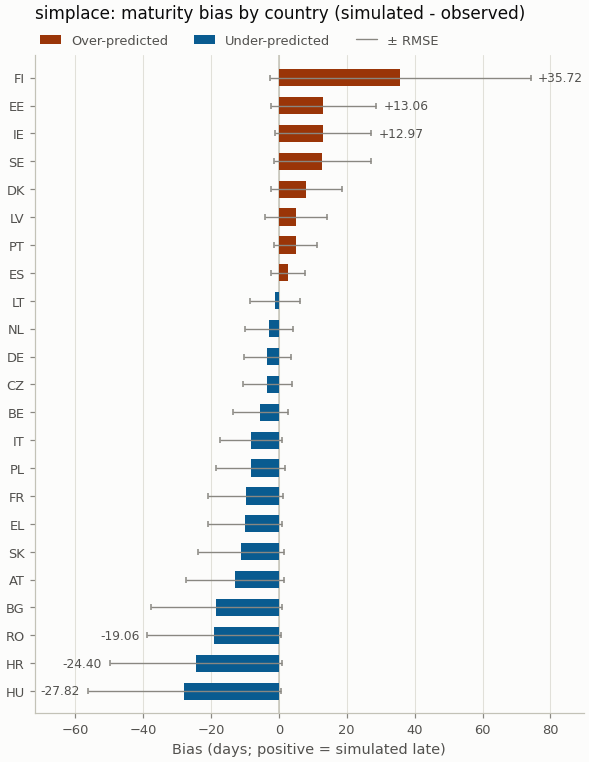

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_03_maturity_bias_torchcrop(.png/.pdf)


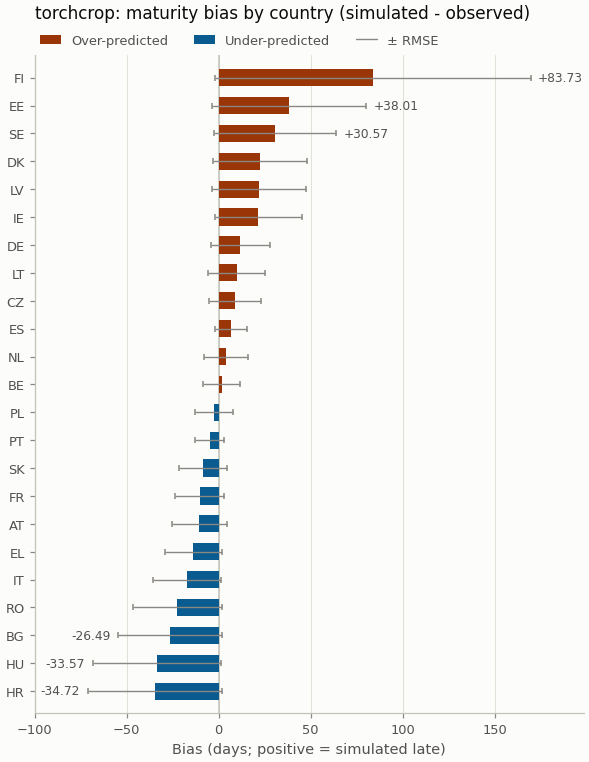

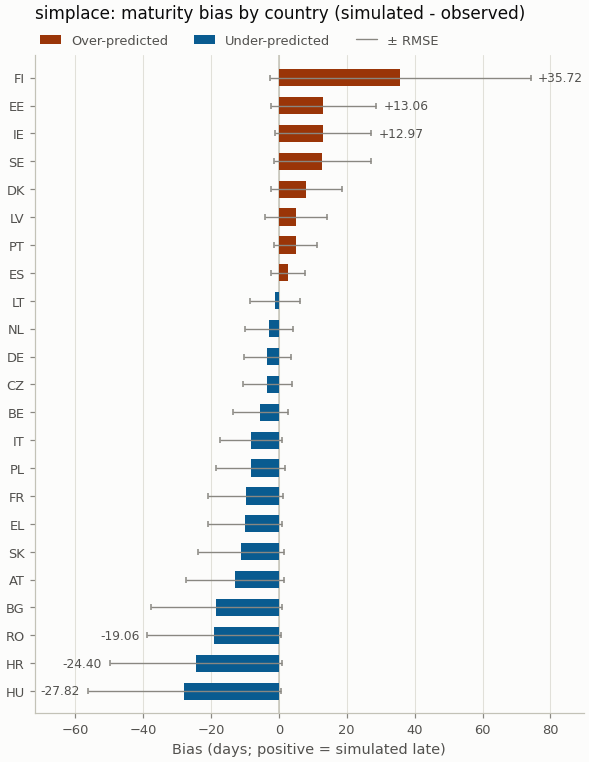

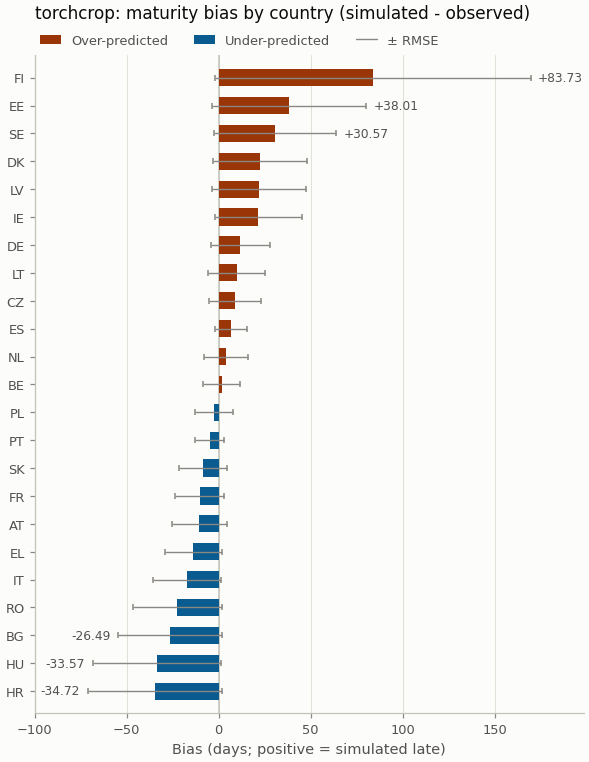

In [17]:
for model, block in phen_paired.groupby("model"):
    stage_metrics = metrics.metrics_by_group(
        block, "eos", "maturity_doy", metric_fn=metrics.phenology_metrics
    )
    ranked = metrics.rank_countries(stage_metrics, by="rmse")
    fig = plots.bias_bars(
        ranked, value_col="bias", error_col="rmse",
        title=f"{model}: maturity bias by country (simulated - observed)",
        xlabel="Bias (days; positive = simulated late)",
    )
    plots.save(fig, f"full_run_03_maturity_bias_{model}")
    display(fig)

### 5.4 Figure — spatial maturity bias, both models

The same country bias as §5.3, on the map — useful here because the sowing
convention mismatch (the §5 caveat) is regional: southern European countries
share an autumn-sowing convention with the model, so where the bias
concentrates says more than the ranked bar chart does.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_08_maturity_bias_map_simplace(.png/.pdf)
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_08_maturity_bias_map_torchcrop(.png/.pdf)


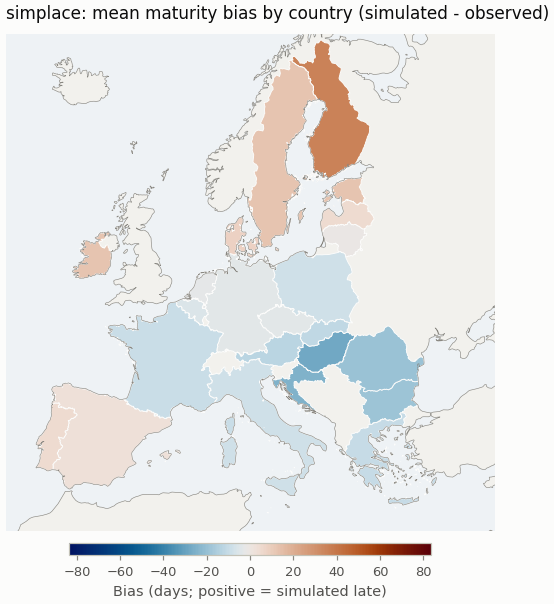

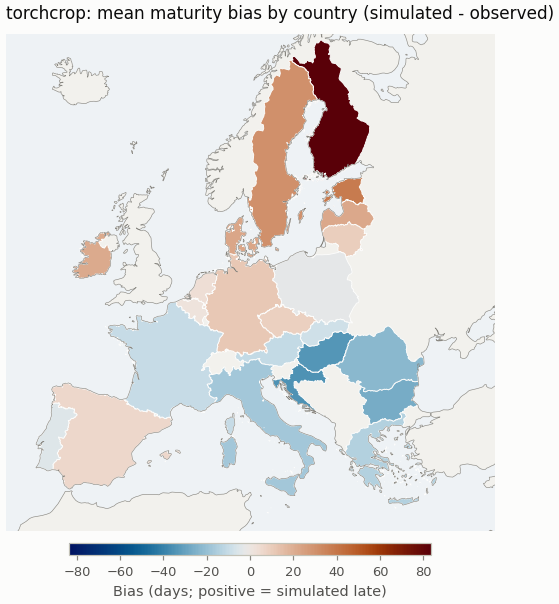

In [18]:
maturity_bias_by_model = {
    model: metrics.metrics_by_group(
        block, "eos", "maturity_doy", metric_fn=metrics.phenology_metrics
    )
    for model, block in phen_paired.groupby("model")
}
maturity_bias_vmax = max(
    table["bias"].abs().max() for table in maturity_bias_by_model.values()
)

for model, stage_metrics in maturity_bias_by_model.items():
    fig = plots.country_choropleth(
        polygons, stage_metrics["bias"],
        cmap=colormaps.vik, vmax=maturity_bias_vmax,
        title=f"{model}: mean maturity bias by country (simulated - observed)",
        cbar_label="Bias (days; positive = simulated late)", diverging=True,
    )
    plots.save(fig, f"full_run_08_maturity_bias_map_{model}")
    # display(fig)

### 5.5 Overview panel — maturity, side by side

Same layout as §4.6, for `maturity_doy` instead of yield: CyBench `eos`, then
each model's circular mean, one shared scale; bias panels share a second.
`obs_calendar` is a **climatology** (`aggregate_observed_calendar` returns no
`year` column — see §5.1), so there is no year-to-year CyBench spread to put
under panel 1 the way §4.6 put yield's inter-annual std there. That axis is
turned off instead of filled with something that isn't what it claims to be.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_12_maturity_overview_panel(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_12_maturity_overview_panel.png')

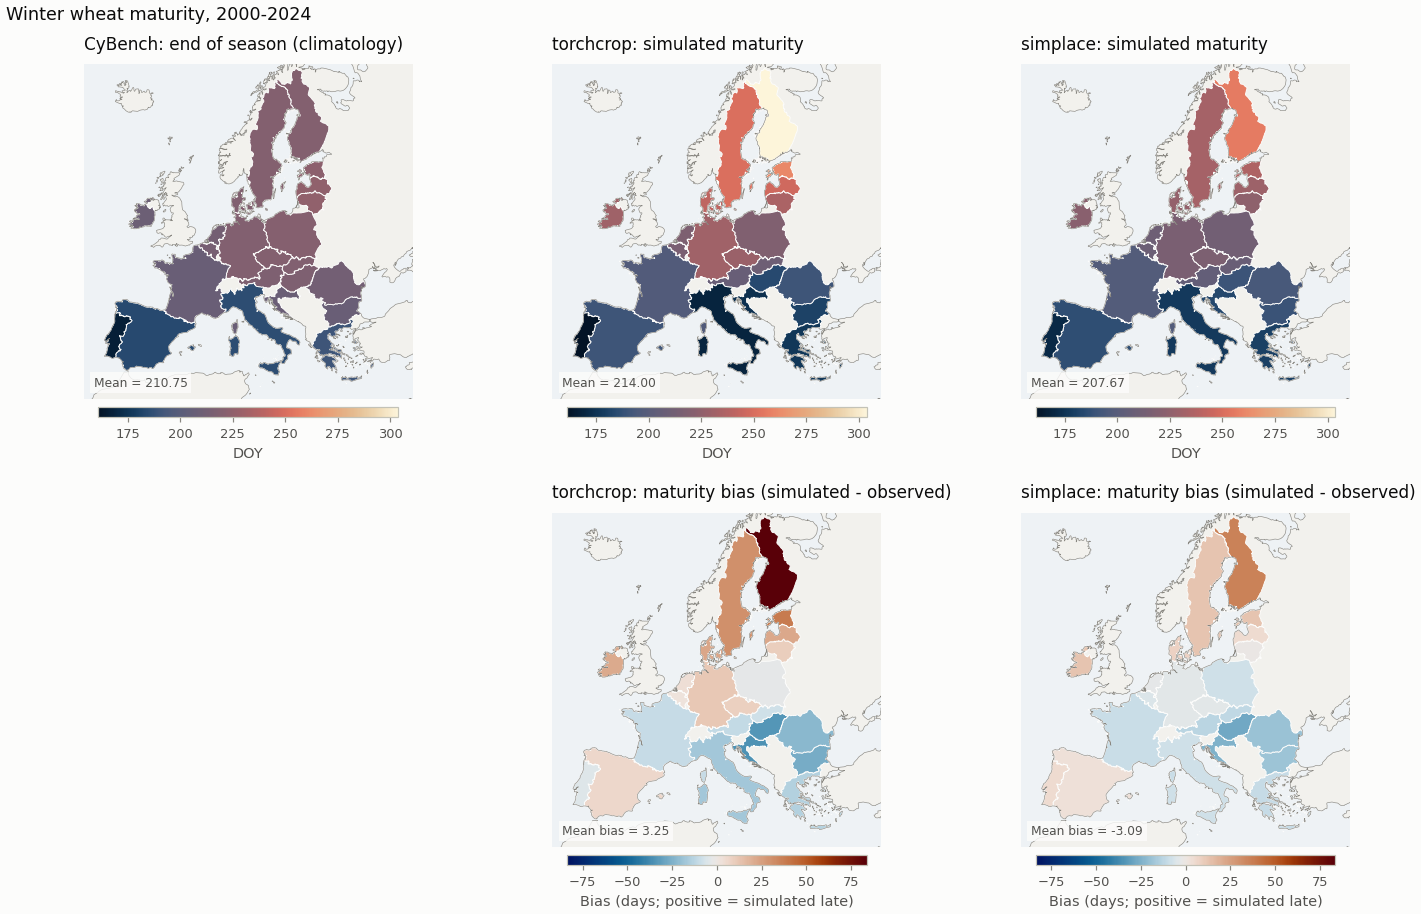

In [19]:
model_order = [m for m in ("torchcrop", "simplace") if m in phen_paired["model"].unique()]
n_cols = 1 + len(model_order)

obs_maturity = obs_calendar.set_index("country")["eos"]
model_maturity_mean = {m: maturity_bias_by_model[m]["sim_mean"] for m in model_order}
model_maturity_bias = {m: maturity_bias_by_model[m]["bias"] for m in model_order}

row1 = [obs_maturity, *model_maturity_mean.values()]
maturity_vmin = min(v.drop("ALL", errors="ignore").min() for v in row1)
maturity_vmax = max(v.drop("ALL", errors="ignore").max() for v in row1)

fig, axes = plt.subplots(
    2, n_cols, figsize=(4.4 * n_cols, 8.6),
    subplot_kw={"projection": plots.EUROPE_PROJECTION},
)

plots.country_choropleth(
    polygons, obs_maturity, ax=axes[0, 0], diverging=False,
    vmin=maturity_vmin, vmax=maturity_vmax, cmap=colormaps.lipari,
    title="CyBench: end of season (climatology)", cbar_label="DOY",
    mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    plots.country_choropleth(
        polygons, model_maturity_mean[m], ax=axes[0, i], diverging=False,
        vmin=maturity_vmin, vmax=maturity_vmax, cmap=colormaps.lipari,
        title=f"{m}: simulated maturity", cbar_label="DOY",
        mean_label="Mean",
    )

axes[1, 0].set_visible(False)  # no year-to-year CyBench spread -- see the note above
for i, m in enumerate(model_order, start=1):
    plots.country_choropleth(
        polygons, model_maturity_bias[m], ax=axes[1, i], diverging=True,
        vmax=maturity_bias_vmax, cmap=colormaps.vik,
        title=f"{m}: maturity bias (simulated - observed)",
        cbar_label="Bias (days; positive = simulated late)", mean_label="Mean bias",
    )

fig.suptitle(
    f"Winter wheat maturity, {min(common_years)}-{max(common_years)}",
    x=0.01, ha="left", color=PALETTE["primary"], fontsize=plt.rcParams["font.size"] + 2,
)
fig.tight_layout()
plots.save(fig, "full_run_12_maturity_overview_panel")
# display(fig)

### 5.6 Overview panel — growing season length, side by side

CyBench publishes no season-length column, only the same climatological
`sos`/`eos` §5.1 already loaded, so it is derived here as the *forward*
wrap across New Year (`(eos - sos) % 365`) — a season length is a duration,
not a bearing, so `doy.doy_difference`'s shortest-path circular error (used
for the maturity *bias* above) is the wrong tool here: it would fold a
~280-day autumn-to-summer season down to whatever is under 182.5 days.
`aggregate.py`'s own rule (*"durations... stay linear"*) is followed the same
way on the simulated side: `torchcrop.add_phenology_columns` already derives
`season_length_days` as `days_to_maturity + harvest_lag_days`; SIMPLACE's
`harvest_doy = maturity_doy` (§5's harvest caveat — `HARVEST_LAG_DAYS = 0`),
so its `days_to_maturity` already *is* the season length. Same climatology
limit as §5.5: no CyBench inter-annual spread to show under panel 1.

INFO cropmodelling4eu.evaluation.aggregate: simulated: 575 country-groups, 3-5300 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 575 rows; 0 simulated-only and 0 observed-only dropped
INFO cropmodelling4eu.evaluation.aggregate: simulated: 575 country-groups, 55-5300 cells each
INFO cropmodelling4eu.evaluation.aggregate: paired 575 rows; 0 simulated-only and 0 observed-only dropped
INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_13_season_length_overview_panel(.png/.pdf)


PosixPath('/data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_13_season_length_overview_panel.png')

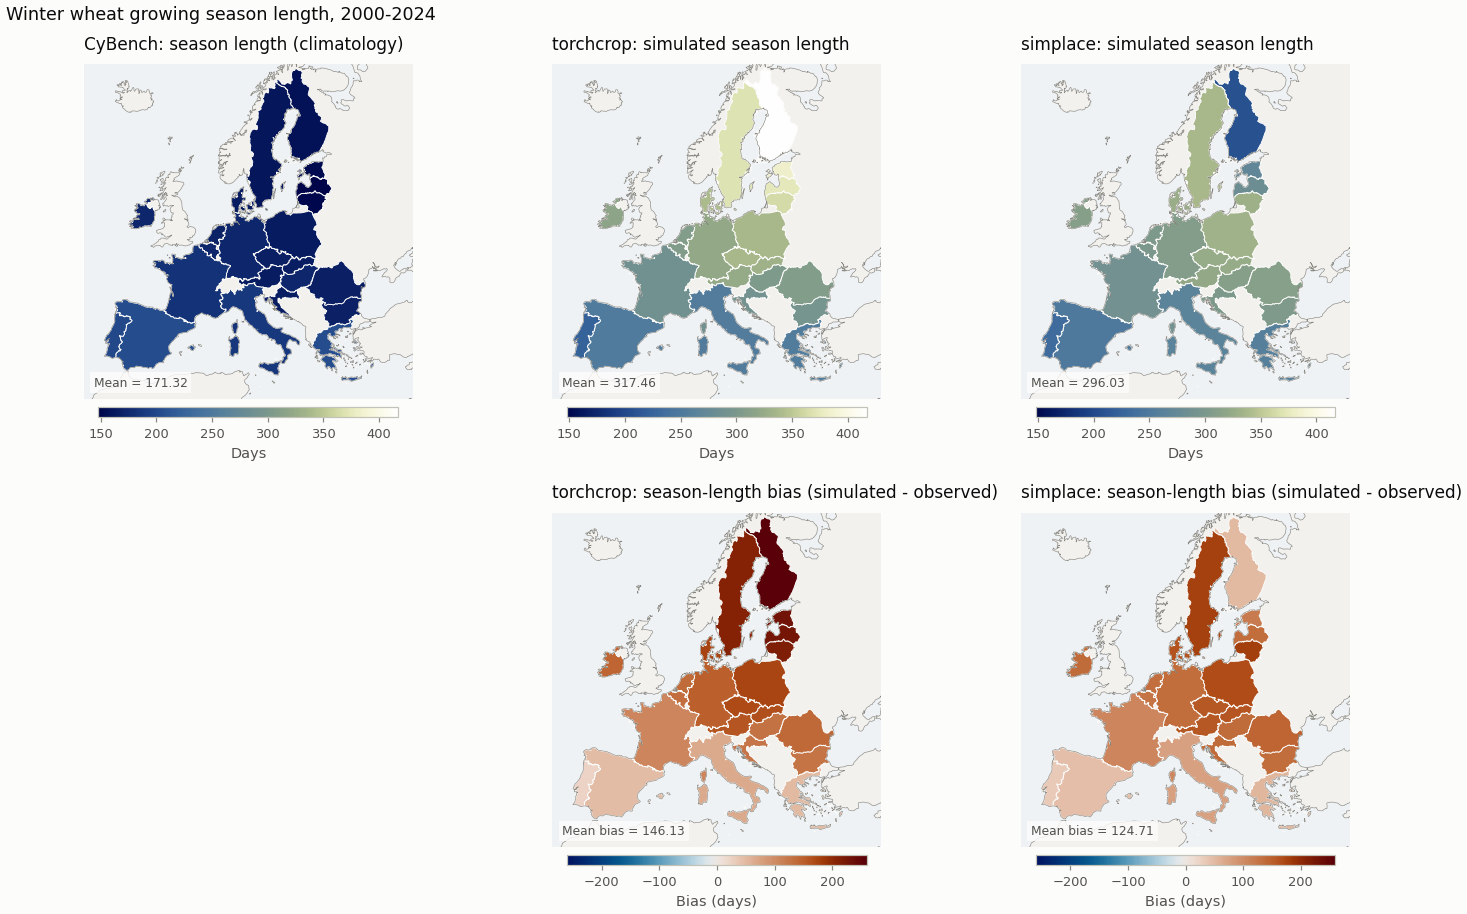

In [20]:
model_order = [m for m in ("torchcrop", "simplace") if m in phen_paired["model"].unique()]
n_cols = 1 + len(model_order)

obs_calendar["obs_season_length_days"] = (
    (obs_calendar["eos"] - obs_calendar["sos"]) % config.DAYS_IN_YEAR
)
obs_season_length = obs_calendar.set_index("country")["obs_season_length_days"]

season_paired = []
for m in model_order:
    frame = scoped[m].copy()
    if "season_length_days" not in frame.columns:
        frame["season_length_days"] = frame["days_to_maturity"]  # SIMPLACE: harvest = maturity
    sim_country = aggregate.aggregate_simulated(frame, {"season_length_days": False})
    paired = aggregate.pair_observations(
        sim_country, obs_calendar[["country", "obs_season_length_days"]], ["country"]
    )
    paired["model"] = m
    season_paired.append(paired)
season_paired = pd.concat(season_paired, ignore_index=True)

# yield_metrics, not phenology_metrics -- a duration, so a plain (not circular) bias.
season_by_country = {
    m: metrics.metrics_by_group(block, "obs_season_length_days", "season_length_days")
    for m, block in season_paired.groupby("model")
}
model_season_mean = {m: season_by_country[m]["sim_mean"] for m in model_order}
model_season_bias = {m: season_by_country[m]["bias"] for m in model_order}
season_bias_vmax = max(
    model_season_bias[m].drop("ALL", errors="ignore").abs().max() for m in model_order
)

row1 = [obs_season_length, *model_season_mean.values()]
season_vmin = min(v.drop("ALL", errors="ignore").min() for v in row1)
season_vmax = max(v.drop("ALL", errors="ignore").max() for v in row1)

fig, axes = plt.subplots(
    2, n_cols, figsize=(4.4 * n_cols, 8.6),
    subplot_kw={"projection": plots.EUROPE_PROJECTION},
)

plots.country_choropleth(
    polygons, obs_season_length, ax=axes[0, 0], diverging=False,
    vmin=season_vmin, vmax=season_vmax, cmap=colormaps.davos,
    title="CyBench: season length (climatology)", cbar_label="Days",
    mean_label="Mean",
)
for i, m in enumerate(model_order, start=1):
    plots.country_choropleth(
        polygons, model_season_mean[m], ax=axes[0, i], diverging=False,
        vmin=season_vmin, vmax=season_vmax, cmap=colormaps.davos,
        title=f"{m}: simulated season length", cbar_label="Days",
        mean_label="Mean",
    )

axes[1, 0].set_visible(False)  # no year-to-year CyBench spread -- see the note above
for i, m in enumerate(model_order, start=1):
    plots.country_choropleth(
        polygons, model_season_bias[m], ax=axes[1, i], diverging=True,
        vmax=season_bias_vmax, cmap=colormaps.vik,
        title=f"{m}: season-length bias (simulated - observed)",
        cbar_label="Bias (days)", mean_label="Mean bias",
    )

fig.suptitle(
    f"Winter wheat growing season length, {min(common_years)}-{max(common_years)}",
    x=0.01, ha="left", color=PALETTE["primary"], fontsize=plt.rcParams["font.size"] + 2,
)
fig.tight_layout()
plots.save(fig, "full_run_13_season_length_overview_panel")
# display(fig)

## 6. SIMPLACE against TorchCrop, directly

**No observation in this section — every number is a difference between the
two models**, signed `torchcrop − simplace` (`fullrun.pair_models`), the same
convention `stresstest_evaluation.ipynb` uses and for the same reason: calling
one side "simulated" and the other "observed" would claim a reference neither
run supports. This section needs both models and is skipped otherwise.

In [21]:
BOTH_MODELS = len(runs) == 2
if not BOTH_MODELS:
    print("Only one model has a finished run -- skipping the direct comparison. "
          "Re-run this notebook once the other has been collected.")
else:
    model_pairs = fullrun.pair_models(runs)
    print(f"{len(model_pairs):,} (cell, year) pairs common to both runs "
          f"(of {len(runs['simplace']):,} simplace, {len(runs['torchcrop']):,} torchcrop)")
    model_pairs.head()

INFO cropmodelling4eu.evaluation.fullrun: 1711510 (cell, year) pairs common to both runs (of 1711510 simplace, 1711510 torchcrop)


1,711,510 (cell, year) pairs common to both runs (of 1,711,510 simplace, 1,711,510 torchcrop)


### 6.1 Do the two runs share a sowing date?

Zero everywhere is what `submit_cropmodelling.sh`'s chained run is *for* —
SIMPLACE's simulated date handed straight to torchcrop's shard array. The
comparison is against the *corrected* SIMPLACE date, not
`simplace_europe.parquet`'s own raw `sowing_doy` column: that column is one
day earlier than the day the crop actually starts growing (the solution's
`DefaultManagement`/`SowingRule` component order means `DoSow` reads
*yesterday's* rule result — see `collect.sowing_table`'s docstring), and
`sowing_from_simplace.csv` corrects it by +1 before torchcrop ever reads it.
`fullrun.pair_models` applies the same +1 before differencing, so a properly
chained run reads 0 here too. Anything else means torchcrop sowed from its
own convention instead (a per-cell site table date, or the DOY 270 constant
for a run made before the site stage), and every later stage in this section
is comparing two different seasons.

In [22]:
if BOTH_MODELS:
    mismatch = (model_pairs["sowing_doy_delta"] != 0).mean()
    print(f"{mismatch:.1%} of paired cell-years sow on a different day.")
    display(model_pairs["sowing_doy_delta"].describe().to_frame())

0.0% of paired cell-years sow on a different day.


,sowing_doy_delta
count,1711510.0
mean,0.0
std,0.0
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,0.0


### 6.2 Agreement, pooled over every paired cell-season

In [23]:
if BOTH_MODELS:
    rows = []
    for key, label, is_date in [
        ("yield_t_ha", "Yield (t/ha)", False),
        ("biomass_g_m2", "Biomass (g/m2)", False),
        ("max_lai", "Peak LAI (m2/m2)", False),
        ("maturity_doy", "Maturity (DOY)", True),
    ]:
        simplace_col, torchcrop_col = f"{key}_simplace", f"{key}_torchcrop"
        if simplace_col not in model_pairs:
            continue
        fn = metrics.phenology_metrics if is_date else metrics.yield_metrics
        rows.append(fn(model_pairs[simplace_col], model_pairs[torchcrop_col]) | {"variable": label})
    agreement = pd.DataFrame(rows).set_index("variable")
    agreement.to_csv(config.TABLE_DIR / "full_run_model_agreement.csv", float_format="%.3f")
    agreement.round(3)

### 6.3 Figure — yield agreement

The 1:1 line is the only reference drawn: there is no observation to regress
on here, so a fitted line would suggest a skill this run cannot measure.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_04_model_agreement_yield(.png/.pdf)


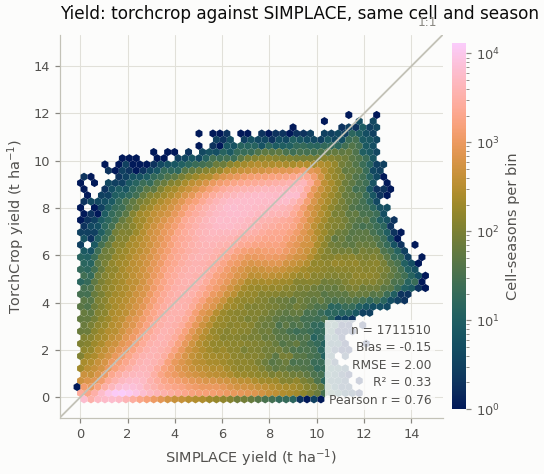

In [24]:
if BOTH_MODELS:
    stats = metrics.yield_metrics(
        model_pairs["yield_t_ha_simplace"], model_pairs["yield_t_ha_torchcrop"]
    )
    fig = plots.scatter_density(
        model_pairs, "yield_t_ha_simplace", "yield_t_ha_torchcrop", stats=stats,
        cmap=colormaps.batlow,
        title="Yield: torchcrop against SIMPLACE, same cell and season",
        xlabel="SIMPLACE yield (t ha$^{-1}$)",
        ylabel="TorchCrop yield (t ha$^{-1}$)",
        cbar_label="Cell-seasons per bin",
    )
    plots.save(fig, "full_run_04_model_agreement_yield")
    # display(fig)

### 6.4 Figure — maturity agreement

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_05_model_agreement_maturity(.png/.pdf)


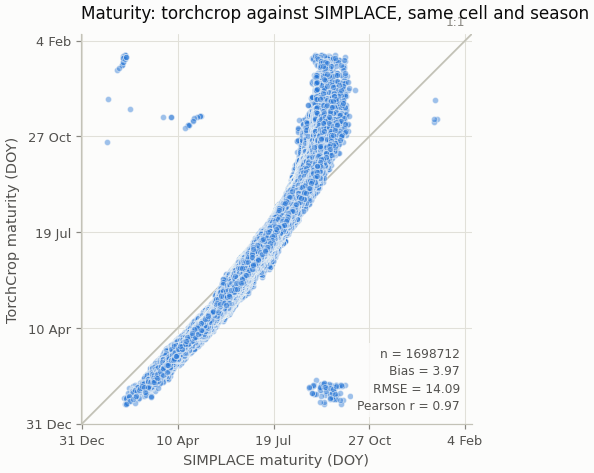

In [25]:
if BOTH_MODELS and "maturity_doy_simplace" in model_pairs:
    stats = metrics.phenology_metrics(
        model_pairs["maturity_doy_simplace"], model_pairs["maturity_doy_torchcrop"]
    )
    fig = plots.scatter_one_to_one(
        model_pairs, "maturity_doy_simplace", "maturity_doy_torchcrop",
        stats=stats, circular=True,
        title="Maturity: torchcrop against SIMPLACE, same cell and season",
        xlabel="SIMPLACE maturity (DOY)",
        ylabel="TorchCrop maturity (DOY)",
    )
    plots.save(fig, "full_run_05_model_agreement_maturity")
    # display(fig)

### 6.5 Figure — spatial map of model disagreement

Signed `torchcrop - simplace` per cell, mean over the paired years — the
spatial counterpart of §6.2's pooled numbers, and the only way to see whether
the disagreement is a uniform offset or concentrated in particular regions.
The §6.1 sowing mismatch, in particular, need not affect every cell the same
way.

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_09_model_agreement_yield_map(.png/.pdf)


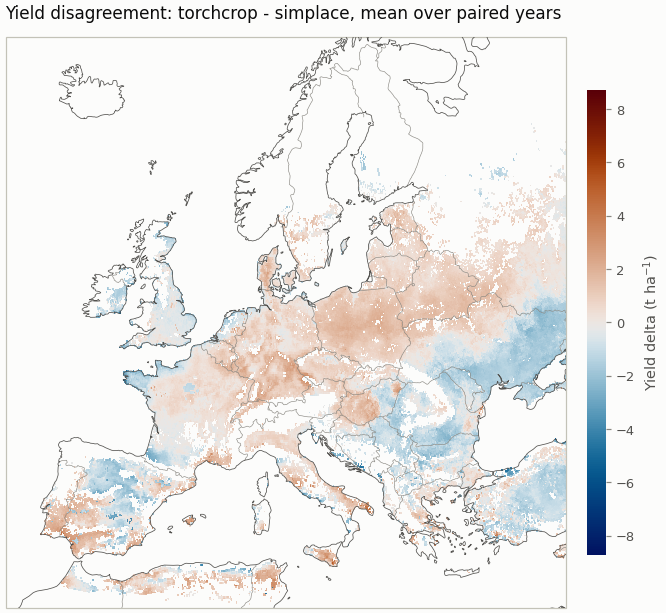

In [26]:
if BOTH_MODELS:
    cell_delta = model_pairs.groupby(
        ["SimplaceID", "lon", "lat"], as_index=False
    )[["yield_t_ha_delta", "maturity_doy_delta"]].mean()

    fig = plots.cell_map(
        cell_delta, "yield_t_ha_delta",
        cmap=plots.DIVERGING_CMAP, norm=plots.diverging_norm(cell_delta["yield_t_ha_delta"]),
        title="Yield disagreement: torchcrop - simplace, mean over paired years",
        cbar_label="Yield delta (t ha$^{-1}$)",
    )
    plots.save(fig, "full_run_09_model_agreement_yield_map")
    # display(fig)

INFO cropmodelling4eu.evaluation.plots: wrote /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures/full_run_10_model_agreement_maturity_map(.png/.pdf)


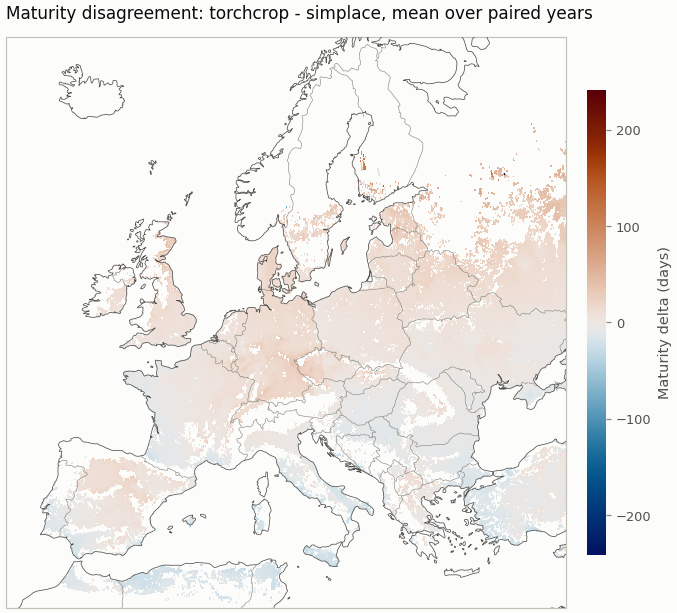

In [27]:
if BOTH_MODELS and "maturity_doy_delta" in model_pairs:
    fig = plots.cell_map(
        cell_delta, "maturity_doy_delta",
        cmap=plots.DIVERGING_CMAP, norm=plots.diverging_norm(cell_delta["maturity_doy_delta"]),
        title="Maturity disagreement: torchcrop - simplace, mean over paired years",
        cbar_label="Maturity delta (days)",
    )
    plots.save(fig, "full_run_10_model_agreement_maturity_map")
    # display(fig)

## 7. Summary

In [28]:
yield_paired.to_csv(config.TABLE_DIR / "full_run_yield_paired.csv",
                    index=False, float_format="%.4f")
phen_paired.to_csv(config.TABLE_DIR / "full_run_phenology_paired.csv",
                   index=False, float_format="%.4f")
if BOTH_MODELS:
    model_pairs.to_csv(config.TABLE_DIR / "full_run_model_pairs.csv",
                       index=False, float_format="%.4f")
print(f"tables written to {config.TABLE_DIR}")
print(f"figures written to {config.FIGURE_DIR}")

summary = pd.DataFrame({
    "yield RMSE (t/ha)": {m: round(v["rmse"], 2) for m, v in yield_pooled.items()},
    "yield Bias (t/ha)": {m: round(v["bias"], 2) for m, v in yield_pooled.items()},
    "yield Pearson r": {m: round(v["pearson_r"], 2) for m, v in yield_pooled.items()},
})
summary

tables written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/tables
figures written to /data01/FDS/muduchuru/codes/GITHUB/data4simplace/cropmodelling4eu/src/cropmodelling4eu/outputs/figures


,yield RMSE (t/ha),yield Bias (t/ha),yield Pearson r
simplace,2.38,0.98,0.28
torchcrop,2.56,1.29,0.31


### What this notebook can and cannot say

* **§4-5 score each model against an external reference**, exactly as the
  single-model notebooks do — a country either model gets wrong is a genuine
  finding there.
* **§6 cannot say which model is right.** It says whether the two production
  runs agree, and §6.1 says how much of any disagreement is simply a different
  sowing convention rather than a model difference — read it before the rest
  of the section.
* **This is the delivered pipeline, not a controlled experiment.** Unlike
  `stresstest_evaluation.ipynb`, nothing here has been forced equal except the
  year range (§2), so a disagreement in §6 can still come from the sowing
  date, the crop parameters, or the model physics — this notebook does not
  separate them. `stresstest_evaluation.ipynb` is where that separation is
  done.
* **Re-run once both arrays finish.** `submit/submit_cropmodelling.sh --status`
  reports what each stage has completed; §2's model list is this notebook's
  own record of what it actually saw.